# Record Audio From Microphone

In [3]:
import sounddevice as sd
import numpy as np

duration = 5  # seconds
sampling_rate = 44100  # Hz

recording = sd.rec(duration * sampling_rate, samplerate=sampling_rate, channels=1)
print("Recording...")
sd.wait()  # Wait until the recording is finished
print("Recording finished.")

Recording...
Recording finished.


In [4]:
print("audio data shape:", recording.shape)
print(recording[-10:])  # Print the last 10 samples of the recording

audio data shape: (220500, 1)
[[ 0.00152588]
 [-0.00076294]
 [ 0.00057983]
 [ 0.00170898]
 [ 0.00131226]
 [ 0.00308228]
 [ 0.00137329]
 [ 0.00161743]
 [ 0.0022583 ]
 [ 0.00192261]]


In [5]:
sd.play(recording, samplerate=sampling_rate)

# Visualize Waveform and Spectrogram

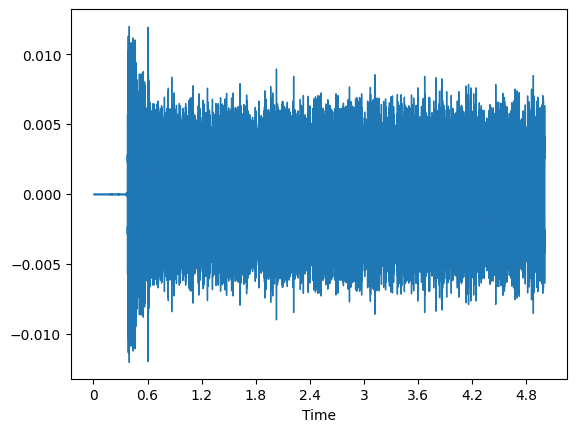

In [6]:
import librosa
import matplotlib.pyplot as plt

librosa.display.waveshow(recording.flatten(), sr=sampling_rate)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24064\449675673.py:3: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D = librosa.amplitude_to_db(librosa.stft(recording.flatten()), ref=np.max)


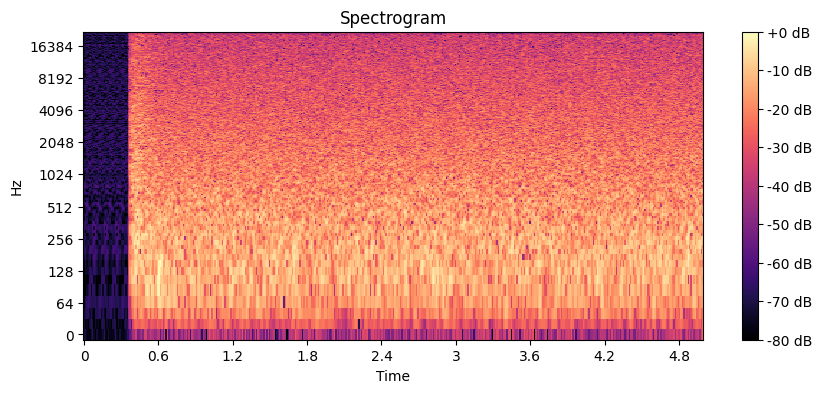

In [7]:
import numpy as np

D = librosa.amplitude_to_db(librosa.stft(recording.flatten()), ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sampling_rate, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

# Spectrogram Examples: Musical Instruments

为了更好地理解 spectrogram，我们来看不同乐器演奏同一个音符时的频谱特征。不同的乐器有不同的泛音结构，这会在 spectrogram 中清晰地表现出来。

# Load and Write Audio File

In [11]:
import soundfile as sf

sf.write("recoding.wav", recording, sampling_rate, subtype="PCM_24")

In [12]:
recording, sampling_rate = sf.read("recoding.wav")
print(recording.shape, sampling_rate)

(220500,) 44100


# Resample

In [13]:
resampled_rate = 16000
resampled_recording = librosa.resample(
    recording.flatten(), orig_sr=sampling_rate, target_sr=resampled_rate
)
print(resampled_recording.shape)

(80000,)


In [14]:
sd.play(resampled_recording, samplerate=resampled_rate)